# AI Metadata Discovery Tutorial — Turning Aviation Documents into Machine Readable Knowledge

## Introduction 
This notebook presents an end-to-end proof of concept for transforming an unstructured aviation PDF into validated, queryable metadata with traceable provenance. While the immediate goal is educational and exploratory, the work also serves as a precursor to a future AeroFlux integration component. This notebook uses NetworkX as a lightweight in-memory knowledge graph, but AeroFlux is expected to use Neo4j for persistent graph storage along with vector databases, a larger FAA document corpus, ontology management, autonomous planning, and integration with the AeroFlux user interface.

For now, the focus is intentionally narrow: demonstrate the core metadata discovery workflow clearly and reliably before expanding it into a production-scale architecture.

## What was Built

The notebook takes an FAA aviation PDF, extracts the text, identifies useful metadata, validates it against our defined schema, and organizes the results into a simple knowledge graph. It then uses that structured metadata and its source evidence to answer questions, while LangGraph coordinates the overall workflow.

## Lessons Learned 

I had been wanting to build something like this for both my personal projects and my professional work, so this prototype was a useful opportunity to explore the full workflow end to end. During the build, I learned how unstructured aviation documents can be transformed into structured, validated metadata that is easier for both humans and AI systems to use. LLMs on their own can struggle to produce semantically precise answers, especially in specialized domains with their own terminology, abbreviations, and conventions, so combining LangExtract with Pydantic validation and explicit provenance makes the results much more reliable and traceable. Once that structured foundation is established, knowledge graphs can represent relationships between entities in ways that are often more expressive than storing isolated fields in traditional tables; graph databases such as Neo4j and its Cypher query language can then be used to explore those relationships directly. Finally, LangGraph and LlamaIndex demonstrate how these components can be orchestrated into a controlled workflow and queried through a grounded AI interface, providing a strong foundation for a future metadata discovery agent.




## Install packages

Depending on your setup and env settings you may have to install ipykernal

In [3]:
%pip install -q \
    "python-dotenv>=1.0,<2" \
    "docling==2.114.0" \
    "langextract==1.6.0" \
    "pydantic>=2.11,<3" \
    "langgraph==1.2.9" \
    "networkx>=3.3,<4" \
    "matplotlib>=3.8,<4" \
    "llama-index-core==0.14.23" \
    "llama-index-llms-google-genai==0.9.6" \
    "llama-index-embeddings-google-genai==0.5.1" \
    "nbconvert[webpdf]"

Note: you may need to restart the kernel to use updated packages.


## Imports and model configuration

One Gemini API key is used for LangExtract and LlamaIndex. The API key is saved in a .env not visable here. Go here if you don't have one: https://aistudio.google.com/ 

In [4]:
import os
import json
import hashlib
import textwrap
from pathlib import Path
from pprint import pprint
from collections import Counter
from typing import Any, TypedDict

from dotenv import load_dotenv
from IPython.display import display, Markdown

# Load environment variables from .env
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.5-flash")
GEMINI_EMBED_MODEL = os.getenv(
    "GEMINI_EMBED_MODEL",
    "gemini-embedding-2",
)

if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY was not found. Add it to your .env file."
    )

print("LLM model:", GEMINI_MODEL)
print("Embedding model:", GEMINI_EMBED_MODEL)
print("API key configured:", bool(GOOGLE_API_KEY))

LLM model: gemini-3.5-flash
Embedding model: gemini-embedding-2
API key configured: True


## Small FAA source document

The bundled `data/sample.pdf` is a **single-page Washington Dulles International Airport (IAD / KIAD) entry** from an FAA Chart Supplement. It contains identifiers, runways, communications, remarks, and restrictions.

Just as some background, the FAA Northeast Chart Supplement is an official flight information publication providing detailed airport data, communication frequencies, and operational procedures for airports, heliports, and seaplane bases across thirteen northeastern states. Updated every 56 days by the FAA, it serves as a critical reference for pilots during preflight planning.


In [5]:
PDF_PATH = Path("data/sample.pdf")

if not PDF_PATH.exists():
    raise FileNotFoundError(
        f"{PDF_PATH} was not found. Start Jupyter from the metadata-agent-notebook-demo folder."
    )

print("Using:", PDF_PATH.resolve())
print(f"File size: {PDF_PATH.stat().st_size / 1024:.1f} KB")

Using: /home/jon/Documents/grad_school/big_data/mods/ai-metadata-discovery-agent-simple/data/sample.pdf
File size: 39.8 KB


## Pydantic metadata schema

The Pydantic metadata schema is used to ensure the information extracted by the LLM follows a consistent, typed structure before it is stored or queried. It also validates fields such as identifiers, runways, confidence scores, and provenance, which helps prevent malformed or incomplete metadata from entering the knowledge graph. 

Every extracted object carries provenance: source document, page, section, supporting text, and confidence. `confidence` is a **model-supplied value**, not a statistically calibrated probability.

In [6]:
from pydantic import BaseModel, ConfigDict, Field, field_validator


class Evidence(BaseModel):
    model_config = ConfigDict(extra="ignore")
    source_document: str
    page: int | None = None
    section: str | None = None
    supporting_text: str
    confidence: float = Field(default=0.85, ge=0.0, le=1.0)


class Airport(Evidence):
    name: str
    canonical_identifier: str | None = None


class Identifier(Evidence):
    value: str
    identifier_type: str = "UNKNOWN"


class Runway(Evidence):
    designator: str
    length_ft: int | None = None
    width_ft: int | None = None
    surface: str | None = None


class CommunicationService(Evidence):
    service: str
    frequency: str | None = None
    details: str | None = None


class OperationalRestriction(Evidence):
    description: str


class Relationship(BaseModel):
    subject: str
    predicate: str
    object: str
    evidence: Evidence
    confidence: float = Field(default=0.85, ge=0.0, le=1.0)

    @field_validator("predicate")
    @classmethod
    def normalize_predicate(cls, value: str) -> str:
        return value.strip().upper().replace(" ", "_").replace("-", "_")


class MetadataBundle(BaseModel):
    airport: Airport
    identifiers: list[Identifier] = Field(default_factory=list)
    runways: list[Runway] = Field(default_factory=list)
    communication_services: list[CommunicationService] = Field(default_factory=list)
    operational_restrictions: list[OperationalRestriction] = Field(default_factory=list)
    relationships: list[Relationship] = Field(default_factory=list)


print("Pydantic metadata models are ready.")

Pydantic metadata models are ready.


## Docling parses the PDF

Docling converts the PDF into a structured document and exports Markdown. This gives the extraction step cleaner, machine-readable text.

In [7]:
from docling.document_converter import DocumentConverter


def load_document(pdf_path: str | Path) -> dict[str, Any]:
    path = Path(pdf_path)
    print(f"[load_document] Docling parsing {path} ...")

    converter = DocumentConverter()
    result = converter.convert(path)
    doc = result.document
    markdown = doc.export_to_markdown()

    pages = getattr(doc, "pages", None)
    page_count = len(pages) if pages is not None else None

    print(f"[load_document] Extracted {len(markdown):,} characters.")
    if page_count:
        print(f"[load_document] Pages detected: {page_count}")

    return {
        "source_document": path.name,
        "page_count": page_count,
        "text": markdown,
    }

/home/jon/Documents/grad_school/big_data/mods/ai-metadata-discovery-agent-simple/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LangExtract: semantic extraction

LangExtract receives a concise prompt plus an example. The examples show the model how to recognize airports, identifiers, runways, communication services, restrictions, and relationships.

`extraction_text` is expected to match source text so the result can retain grounding information.

In [8]:
import langextract as lx


EXTRACTION_PROMPT = textwrap.dedent("""
    Extract aviation metadata from an FAA airport entry.

    Stay grounded in the supplied text. Use exact source text for extraction_text.
    Do not invent missing facts.

    Extraction classes and attributes:
    - airport: name, canonical_identifier, section, confidence
    - identifier: value, identifier_type, section, confidence
    - runway: designator, length_ft, width_ft, surface, airport, section, confidence
    - communication_service: service, frequency, details, airport, section, confidence
    - operational_restriction: description, airport, section, confidence
    - relationship: subject, predicate, object, section, confidence

    Useful relationship predicates:
    HAS_IDENTIFIER, HAS_RUNWAY, HAS_COMMUNICATION_SERVICE,
    HAS_OPERATIONAL_RESTRICTION, USES_FREQUENCY.

    Rules:
    - Prefer canonical runway designators such as 01L/19R or 12/30.
    - Keep communication service/frequency pairs separate when practical.
    - Extract only a few meaningful operational restrictions.
    - Confidence must be between 0 and 1.
""").strip()


EXAMPLES = [
    lx.data.ExampleData(
        text=textwrap.dedent("""
            TEST MUNICIPAL (TST)(KTST)
            RWY 04-22: H5000X100 (ASPH)
            COMMUNICATIONS: ATIS 118.50 UNICOM 122.80
            AIRPORT REMARKS: RWY 22 CLSD 0400-1000Z.
        """).strip(),
        extractions=[
            lx.data.Extraction(
                extraction_class="airport",
                extraction_text="TEST MUNICIPAL",
                attributes={
                    "name": "TEST MUNICIPAL",
                    "canonical_identifier": "KTST",
                    "section": "AIRPORT",
                    "confidence": 0.99,
                },
            ),
            lx.data.Extraction(
                extraction_class="identifier",
                extraction_text="TST",
                attributes={
                    "value": "TST",
                    "identifier_type": "FAA/IATA",
                    "section": "AIRPORT",
                    "confidence": 0.99,
                },
            ),
            lx.data.Extraction(
                extraction_class="identifier",
                extraction_text="KTST",
                attributes={
                    "value": "KTST",
                    "identifier_type": "ICAO",
                    "section": "AIRPORT",
                    "confidence": 0.99,
                },
            ),
            lx.data.Extraction(
                extraction_class="runway",
                extraction_text="RWY 04-22: H5000X100 (ASPH)",
                attributes={
                    "designator": "04/22",
                    "length_ft": 5000,
                    "width_ft": 100,
                    "surface": "ASPH",
                    "airport": "KTST",
                    "section": "RUNWAY",
                    "confidence": 0.98,
                },
            ),
            lx.data.Extraction(
                extraction_class="communication_service",
                extraction_text="ATIS 118.50",
                attributes={
                    "service": "ATIS",
                    "frequency": "118.50",
                    "airport": "KTST",
                    "section": "COMMUNICATIONS",
                    "confidence": 0.98,
                },
            ),
            lx.data.Extraction(
                extraction_class="operational_restriction",
                extraction_text="RWY 22 CLSD 0400-1000Z",
                attributes={
                    "description": "RWY 22 CLSD 0400-1000Z",
                    "airport": "KTST",
                    "section": "AIRPORT REMARKS",
                    "confidence": 0.97,
                },
            ),
        ],
    ),
    lx.data.ExampleData(
        text="KTST HAS_RUNWAY 04/22. ATIS USES_FREQUENCY 118.50.",
        extractions=[
            lx.data.Extraction(
                extraction_class="relationship",
                extraction_text="KTST HAS_RUNWAY 04/22",
                attributes={
                    "subject": "KTST",
                    "predicate": "HAS_RUNWAY",
                    "object": "04/22",
                    "section": "RELATIONSHIP",
                    "confidence": 0.99,
                },
            ),
            lx.data.Extraction(
                extraction_class="relationship",
                extraction_text="ATIS USES_FREQUENCY 118.50",
                attributes={
                    "subject": "ATIS",
                    "predicate": "USES_FREQUENCY",
                    "object": "118.50",
                    "section": "RELATIONSHIP",
                    "confidence": 0.99,
                },
            ),
        ],
    ),
]


def _raw_extraction(extraction: Any) -> dict[str, Any]:
    attrs = dict(getattr(extraction, "attributes", None) or {})
    interval = getattr(extraction, "char_interval", None)
    return {
        "class": getattr(extraction, "extraction_class", "unknown"),
        "text": getattr(extraction, "extraction_text", ""),
        "attributes": attrs,
        "grounded": interval is not None,
        "char_interval": None if interval is None else {
            "start": getattr(interval, "start_pos", getattr(interval, "start", None)),
            "end": getattr(interval, "end_pos", getattr(interval, "end", None)),
        },
    }


def extract_metadata(text: str, retry: bool = False) -> list[dict[str, Any]]:
    prompt = EXTRACTION_PROMPT
    if retry:
        prompt += "\nRetry conservatively. Use the requested attributes exactly and omit uncertain extractions."

    print(f"[extract_metadata] LangExtract using {GEMINI_MODEL}; retry={retry}")

    result = lx.extract(
        text_or_documents=text,
        prompt_description=prompt,
        examples=EXAMPLES,
        model_id=GEMINI_MODEL,
        api_key=os.environ["GOOGLE_API_KEY"],
        extraction_passes=1,
        max_workers=1,
        max_char_buffer=6000,
        temperature=0.0,
        show_progress=False,
    )

    raw = [_raw_extraction(item) for item in result.extractions]
    grounded = [item for item in raw if item["grounded"]]
    if grounded:
        raw = grounded

    print("[extract_metadata] Counts:", dict(Counter(x["class"] for x in raw)))
    return raw

## Pydantic validation and relationship resolution

The LLM proposes metadata, but it does **not** directly control the final graph. The validated entities are converted into a small, deterministic relationship set.

In [9]:
def _number(value: Any, default: float = 0.85) -> float:
    try:
        return max(0.0, min(1.0, float(value)))
    except (TypeError, ValueError):
        return default


def _integer(value: Any) -> int | None:
    if value in (None, ""):
        return None
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return None


def _evidence(item: dict[str, Any], source_document: str, page: int | None) -> dict[str, Any]:
    attrs = item.get("attributes") or {}
    return {
        "source_document": source_document,
        "page": page,
        "section": attrs.get("section"),
        "supporting_text": str(item.get("text") or "").strip(),
        "confidence": _number(attrs.get("confidence")),
    }


def validate_extractions(raw, source_document, page_count) -> MetadataBundle:
    page = 1 if page_count == 1 else None
    airports, identifiers, runways, comms, restrictions, extracted_relationships = [], [], [], [], [], []

    for item in raw:
        cls = str(item.get("class") or "").lower()
        attrs = item.get("attributes") or {}
        ev = _evidence(item, source_document, page)

        if cls == "airport":
            airport = Airport(
                **ev,
                name=str(attrs.get("name") or item.get("text") or "").strip(),
                canonical_identifier=(str(attrs["canonical_identifier"]).strip() if attrs.get("canonical_identifier") else None),
            )
            if airport.name:
                airports.append(airport)

        elif cls == "identifier":
            value = str(attrs.get("value") or item.get("text") or "").strip(" ()")
            if value:
                identifiers.append(Identifier(**ev, value=value, identifier_type=str(attrs.get("identifier_type") or "UNKNOWN")))

        elif cls == "runway":
            designator = str(attrs.get("designator") or "").strip().replace("-", "/")
            if designator:
                runways.append(Runway(
                    **ev,
                    designator=designator,
                    length_ft=_integer(attrs.get("length_ft")),
                    width_ft=_integer(attrs.get("width_ft")),
                    surface=(str(attrs["surface"]).strip() if attrs.get("surface") else None),
                ))

        elif cls == "communication_service":
            service = str(attrs.get("service") or "").strip()
            if service:
                comms.append(CommunicationService(
                    **ev,
                    service=service,
                    frequency=(str(attrs["frequency"]).strip() if attrs.get("frequency") else None),
                    details=(str(attrs["details"]).strip() if attrs.get("details") else None),
                ))

        elif cls == "operational_restriction":
            description = str(attrs.get("description") or item.get("text") or "").strip()
            if description:
                restrictions.append(OperationalRestriction(**ev, description=description))

        elif cls == "relationship":
            subject = str(attrs.get("subject") or "").strip()
            predicate = str(attrs.get("predicate") or "").strip()
            obj = str(attrs.get("object") or "").strip()
            if subject and predicate and obj:
                extracted_relationships.append(Relationship(
                    subject=subject,
                    predicate=predicate,
                    object=obj,
                    evidence=Evidence(**ev),
                    confidence=ev["confidence"],
                ))

    if not airports:
        raise ValueError("Validation failed: LangExtract did not identify an airport.")

    return MetadataBundle(
        airport=airports[0],
        identifiers=identifiers,
        runways=runways,
        communication_services=comms,
        operational_restrictions=restrictions,
        relationships=extracted_relationships,
    )


def resolve_relationships(bundle: MetadataBundle) -> MetadataBundle:
    airport_id = bundle.airport.canonical_identifier or (bundle.identifiers[0].value if bundle.identifiers else bundle.airport.name)
    relationships = list(bundle.relationships)
    seen = {(r.subject, r.predicate, r.object) for r in relationships}

    def add(subject, predicate, obj, entity):
        key = (subject, predicate, obj)
        if key in seen:
            return
        relationships.append(Relationship(
            subject=subject,
            predicate=predicate,
            object=obj,
            evidence=Evidence(**entity.model_dump()),
            confidence=entity.confidence,
        ))
        seen.add(key)

    for item in bundle.identifiers:
        add(airport_id, "HAS_IDENTIFIER", item.value, item)
    for item in bundle.runways:
        add(airport_id, "HAS_RUNWAY", item.designator, item)
    for item in bundle.communication_services:
        add(airport_id, "HAS_COMMUNICATION_SERVICE", item.service, item)
        if item.frequency:
            add(item.service, "USES_FREQUENCY", item.frequency, item)
    for item in bundle.operational_restrictions:
        add(airport_id, "HAS_OPERATIONAL_RESTRICTION", item.description, item)

    return bundle.model_copy(update={"relationships": relationships})

## In-memory knowledge graph

The graph uses labels and predicates that can later map directly to Neo4j nodes and relationships. This will be a later project. 

In [10]:
import networkx as nx


def _node_key(label: str, value: str) -> str:
    return f"{label}:{value}"


def build_knowledge_graph(bundle: MetadataBundle) -> nx.MultiDiGraph:
    G = nx.MultiDiGraph()

    doc_key = _node_key("Document", bundle.airport.source_document)
    G.add_node(doc_key, label="Document", display=bundle.airport.source_document, source_document=bundle.airport.source_document)

    airport_display = bundle.airport.canonical_identifier or bundle.airport.name
    airport_key = _node_key("Airport", airport_display)
    G.add_node(airport_key, label="Airport", display=airport_display, payload=bundle.airport.model_dump())
    G.add_edge(airport_key, doc_key, predicate="SUPPORTED_BY", evidence=bundle.airport.supporting_text, page=bundle.airport.page)

    lookup = {("Airport", airport_display): airport_key}

    for item in bundle.identifiers:
        key = _node_key("Identifier", item.value)
        G.add_node(key, label="Identifier", display=item.value, payload=item.model_dump())
        lookup[("Identifier", item.value)] = key
        G.add_edge(key, doc_key, predicate="SUPPORTED_BY", evidence=item.supporting_text, page=item.page)

    for item in bundle.runways:
        key = _node_key("Runway", item.designator)
        G.add_node(key, label="Runway", display=item.designator, payload=item.model_dump())
        lookup[("Runway", item.designator)] = key
        G.add_edge(key, doc_key, predicate="SUPPORTED_BY", evidence=item.supporting_text, page=item.page)

    for i, item in enumerate(bundle.communication_services):
        key = _node_key("CommunicationService", f"{item.service}:{item.frequency or i}")
        G.add_node(key, label="CommunicationService", display=item.service, payload=item.model_dump())
        lookup.setdefault(("CommunicationService", item.service), key)
        G.add_edge(key, doc_key, predicate="SUPPORTED_BY", evidence=item.supporting_text, page=item.page)
        if item.frequency:
            fkey = _node_key("Frequency", item.frequency)
            G.add_node(fkey, label="Frequency", display=item.frequency, payload={
                "value": item.frequency,
                "source_document": item.source_document,
                "page": item.page,
                "section": item.section,
                "supporting_text": item.supporting_text,
                "confidence": item.confidence,
            })
            lookup[("Frequency", item.frequency)] = fkey

    for item in bundle.operational_restrictions:
        digest = hashlib.sha1(item.description.encode()).hexdigest()[:10]
        key = _node_key("OperationalRestriction", digest)
        G.add_node(key, label="OperationalRestriction", display=item.description, payload=item.model_dump())
        lookup[("OperationalRestriction", item.description)] = key
        G.add_edge(key, doc_key, predicate="SUPPORTED_BY", evidence=item.supporting_text, page=item.page)

    label_pairs = {
        "HAS_IDENTIFIER": ("Airport", "Identifier"),
        "HAS_RUNWAY": ("Airport", "Runway"),
        "HAS_COMMUNICATION_SERVICE": ("Airport", "CommunicationService"),
        "HAS_OPERATIONAL_RESTRICTION": ("Airport", "OperationalRestriction"),
        "USES_FREQUENCY": ("CommunicationService", "Frequency"),
    }

    for rel in bundle.relationships:
        pair = label_pairs.get(rel.predicate)
        if not pair:
            continue
        subject_label, object_label = pair
        source = lookup.get((subject_label, rel.subject))
        target = lookup.get((object_label, rel.object))
        if source and target:
            G.add_edge(
                source,
                target,
                predicate=rel.predicate,
                evidence=rel.evidence.supporting_text,
                source_document=rel.evidence.source_document,
                page=rel.evidence.page,
                confidence=rel.confidence,
            )

    return G


def print_graph(G: nx.MultiDiGraph) -> None:
    print("NODES")
    for _, attrs in G.nodes(data=True):
        print(f"  ({attrs.get('label')}) {attrs.get('display')}")

    print("\nRELATIONSHIPS")
    for source, target, attrs in G.edges(data=True):
        print(f"  {G.nodes[source].get('display')} --{attrs.get('predicate')}--> {G.nodes[target].get('display')}")

## LangGraph workflow

LangGraph is used as a controlled state machine rather than an autonomous planner.

In [11]:
from langgraph.graph import StateGraph, START, END


class WorkflowState(TypedDict, total=False):
    pdf_path: str
    source_document: str
    page_count: int | None
    text: str
    raw_extractions: list[dict[str, Any]]
    bundle: MetadataBundle
    graph: nx.MultiDiGraph
    validation_errors: list[str]
    retries: int
    ready: bool


def load_document_node(state: WorkflowState) -> dict:
    return load_document(state["pdf_path"])


def extract_metadata_node(state: WorkflowState) -> dict:
    return {"raw_extractions": extract_metadata(state["text"], retry=state.get("retries", 0) > 0)}


def validate_metadata_node(state: WorkflowState) -> dict:
    try:
        bundle = validate_extractions(state["raw_extractions"], state["source_document"], state.get("page_count"))
        print(
            "[validate_metadata] Pydantic validation passed:",
            f"{len(bundle.identifiers)} identifiers,",
            f"{len(bundle.runways)} runways,",
            f"{len(bundle.communication_services)} communication services,",
            f"{len(bundle.operational_restrictions)} restrictions.",
        )
        return {"bundle": bundle, "validation_errors": []}
    except Exception as exc:
        retries = state.get("retries", 0) + 1
        print(f"[validate_metadata] Validation failed: {exc}")
        return {"validation_errors": [str(exc)], "retries": retries}


def validation_route(state: WorkflowState):
    if not state.get("validation_errors"):
        return "resolve_relationships"
    if state.get("retries", 0) <= 1:
        print("[validate_metadata] Retrying extraction once...")
        return "extract_metadata"
    print("[validate_metadata] Retry failed; stopping workflow.")
    return END


def resolve_relationships_node(state: WorkflowState) -> dict:
    bundle = resolve_relationships(state["bundle"])
    print(f"[resolve_relationships] Resolved {len(bundle.relationships)} relationships.")
    return {"bundle": bundle}


def store_graph_node(state: WorkflowState) -> dict:
    graph = build_knowledge_graph(state["bundle"])
    print(f"[store_graph] Graph contains {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.")
    return {"graph": graph}


def ready_for_query_node(state: WorkflowState) -> dict:
    print("[ready_for_query] Metadata is ready for retrieval and Q&A.")
    return {"ready": True}


builder = StateGraph(WorkflowState)
builder.add_node("load_document", load_document_node)
builder.add_node("extract_metadata", extract_metadata_node)
builder.add_node("validate_metadata", validate_metadata_node)
builder.add_node("resolve_relationships", resolve_relationships_node)
builder.add_node("store_graph", store_graph_node)
builder.add_node("ready_for_query", ready_for_query_node)

builder.add_edge(START, "load_document")
builder.add_edge("load_document", "extract_metadata")
builder.add_edge("extract_metadata", "validate_metadata")
builder.add_conditional_edges(
    "validate_metadata",
    validation_route,
    {
        "resolve_relationships": "resolve_relationships",
        "extract_metadata": "extract_metadata",
        END: END,
    },
)
builder.add_edge("resolve_relationships", "store_graph")
builder.add_edge("store_graph", "ready_for_query")
builder.add_edge("ready_for_query", END)

workflow = builder.compile()
print("LangGraph workflow compiled.")

LangGraph workflow compiled.


# Run the complete pipeline

This is the main demonstration cell. It should visibly print each workflow stage.

In [12]:
result = workflow.invoke({
    "pdf_path": str(PDF_PATH),
    "retries": 0,
    "validation_errors": [],
})

print("\nWorkflow ready:", result.get("ready", False))
if not result.get("ready"):
    pprint(result.get("validation_errors"))

[load_document] Docling parsing data/sample.pdf ...


[INFO] 2026-08-09 13:22:09,766 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-09 13:22:09,768 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-08-09 13:22:09,778 [RapidOCR] download_file.py:60: File exists and is valid: /home/jon/Documents/grad_school/big_data/mods/ai-metadata-discovery-agent-simple/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-08-09 13:22:09,779 [RapidOCR] main.py:50: Using /home/jon/Documents/grad_school/big_data/mods/ai-metadata-discovery-agent-simple/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-08-09 13:22:09,907 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-09 13:22:09,908 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-08-09 13:22:09,910 [RapidOCR] download_file.py:60: File exists and is valid: /home/jon/Documents/grad_school/big_data/mods/ai-metadata-discovery-agent-simple/.venv/lib/python3.12/site-packages/rapidocr/m

[load_document] Extracted 4,243 characters.
[load_document] Pages detected: 1
[extract_metadata] LangExtract using gemini-3.5-flash; retry=False
[extract_metadata] Counts: {'airport': 1, 'identifier': 2, 'runway': 4, 'communication_service': 2, 'operational_restriction': 2}
[validate_metadata] Pydantic validation passed: 2 identifiers, 4 runways, 2 communication services, 2 restrictions.
[resolve_relationships] Resolved 12 relationships.
[store_graph] Graph contains 14 nodes and 23 edges.
[ready_for_query] Metadata is ready for retrieval and Q&A.

Workflow ready: True


## Inspect each intermediate result

In [13]:
print("DOCLING PARSED TEXT — first 4,000 characters")
print("=" * 80)
print(result["text"][:4000])

DOCLING PARSED TEXT — first 4,000 characters
```
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -WASHINGTON DULLES INTL (IAD)( KIAD ) 20 W UTC-5(-4DT) N38º56.85´ W77º27.60´ 312 B LRA Class I, ARFF Index E NOTAM FILE IAD RWY 01C-19C: H11500X150 (CONC-GRVD) S-200, D-250, 2D-450, 2D/2D2-875 PCR 1089 R/B/W/T HIRL CL RWY 01C: MALSR. TDZL. PAPI(P4L)-GA 3.0º TCH 70´. RVR-TMR RWY 19C: ALSF2. TDZL. PAPI(P4R)-GA 3.0º TCH 72´. RVR-TMR RWY 01R-19L: H11500X150 (CONC-GRVD) S-200, D-250, 2D-450, 2D/2D2-875 PCR 1005 R/B/W/U HIRL CL RWY 01R: ALSF2. TDZL. PAPI(P4R)-GA 3.0º TCH 72´. RVR-TMR RWY 19L: ALSF2. PAPI(P4L)-GA 3.0º TCH 75´. RVR-TMR Pole. 0.3% up. RWY 12-30: H10501X150 (CONC-GRVD) S-200, D-250, 2D-450, 2D/2D2-875 PCR 1108 R/B/W/T HIRL CL RWY 12: MALSR. TDZL. PAPI(P4R)-GA 3.0º TCH 66´. RVR-TR 0.3% down. RWY 30: REIL. PAPI(P4L)-GA 3.0º TCH 84´. RVR-TR RWY 01L-19R: H9400X150 (CONC-GRVD) S-200, D-250, 2D-450, 2D/2D2-875 PCR 1045 R/B/W/T H

In [14]:
print("LANGEXTRACT GROUNDED EXTRACTIONS")
print("=" * 80)
print(json.dumps(result["raw_extractions"], indent=2, ensure_ascii=False))

LANGEXTRACT GROUNDED EXTRACTIONS
[
  {
    "class": "airport",
    "text": "WASHINGTON DULLES INTL",
    "attributes": {
      "name": "WASHINGTON DULLES INTL",
      "canonical_identifier": "KIAD",
      "section": "AIRPORT",
      "confidence": "0.99"
    },
    "grounded": true,
    "char_interval": {
      "start": 115,
      "end": 137
    }
  },
  {
    "class": "identifier",
    "text": "IAD",
    "attributes": {
      "value": "IAD",
      "identifier_type": "FAA/IATA",
      "section": "AIRPORT",
      "confidence": "0.99"
    },
    "grounded": true,
    "char_interval": {
      "start": 139,
      "end": 142
    }
  },
  {
    "class": "identifier",
    "text": "KIAD",
    "attributes": {
      "value": "KIAD",
      "identifier_type": "ICAO",
      "section": "AIRPORT",
      "confidence": "0.99"
    },
    "grounded": true,
    "char_interval": {
      "start": 145,
      "end": 149
    }
  },
  {
    "class": "runway",
    "text": "RWY 01C-19C: H11500X150 (CONC-GRVD)",
  

In [15]:
print("PYDANTIC-VALIDATED METADATA")
print("=" * 80)
print(json.dumps(result["bundle"].model_dump(), indent=2, ensure_ascii=False))

PYDANTIC-VALIDATED METADATA
{
  "airport": {
    "source_document": "sample.pdf",
    "page": 1,
    "section": "AIRPORT",
    "supporting_text": "WASHINGTON DULLES INTL",
    "confidence": 0.99,
    "name": "WASHINGTON DULLES INTL",
    "canonical_identifier": "KIAD"
  },
  "identifiers": [
    {
      "source_document": "sample.pdf",
      "page": 1,
      "section": "AIRPORT",
      "supporting_text": "IAD",
      "confidence": 0.99,
      "value": "IAD",
      "identifier_type": "FAA/IATA"
    },
    {
      "source_document": "sample.pdf",
      "page": 1,
      "section": "AIRPORT",
      "supporting_text": "KIAD",
      "confidence": 0.99,
      "value": "KIAD",
      "identifier_type": "ICAO"
    }
  ],
  "runways": [
    {
      "source_document": "sample.pdf",
      "page": 1,
      "section": "RUNWAY",
      "supporting_text": "RWY 01C-19C: H11500X150 (CONC-GRVD)",
      "confidence": 0.98,
      "designator": "01C/19C",
      "length_ft": 11500,
      "width_ft": 150,
     

In [16]:
print("KNOWLEDGE GRAPH")
print("=" * 80)
print_graph(result["graph"])

KNOWLEDGE GRAPH
NODES
  (Document) sample.pdf
  (Airport) KIAD
  (Identifier) IAD
  (Identifier) KIAD
  (Runway) 01C/19C
  (Runway) 01R/19L
  (Runway) 12/30
  (Runway) 01L/19R
  (CommunicationService) D-ATIS
  (Frequency) 134.85
  (CommunicationService) UNICOM
  (Frequency) 122.95
  (OperationalRestriction) Flt trng btn 0300-1200Z‡ prohibited.
  (OperationalRestriction) B747-8 rstd to max taxi speed 17 kt (20 MPH) on Twy J.

RELATIONSHIPS
  KIAD --SUPPORTED_BY--> sample.pdf
  KIAD --HAS_IDENTIFIER--> IAD
  KIAD --HAS_IDENTIFIER--> KIAD
  KIAD --HAS_RUNWAY--> 01C/19C
  KIAD --HAS_RUNWAY--> 01R/19L
  KIAD --HAS_RUNWAY--> 12/30
  KIAD --HAS_RUNWAY--> 01L/19R
  KIAD --HAS_COMMUNICATION_SERVICE--> D-ATIS
  KIAD --HAS_COMMUNICATION_SERVICE--> UNICOM
  KIAD --HAS_OPERATIONAL_RESTRICTION--> Flt trng btn 0300-1200Z‡ prohibited.
  KIAD --HAS_OPERATIONAL_RESTRICTION--> B747-8 rstd to max taxi speed 17 kt (20 MPH) on Twy J.
  IAD --SUPPORTED_BY--> sample.pdf
  KIAD --SUPPORTED_BY--> sample.pdf
  0

## Visualize the graph

A persistent implementation could write this same node/edge model to Neo4j and query it with Cypher.

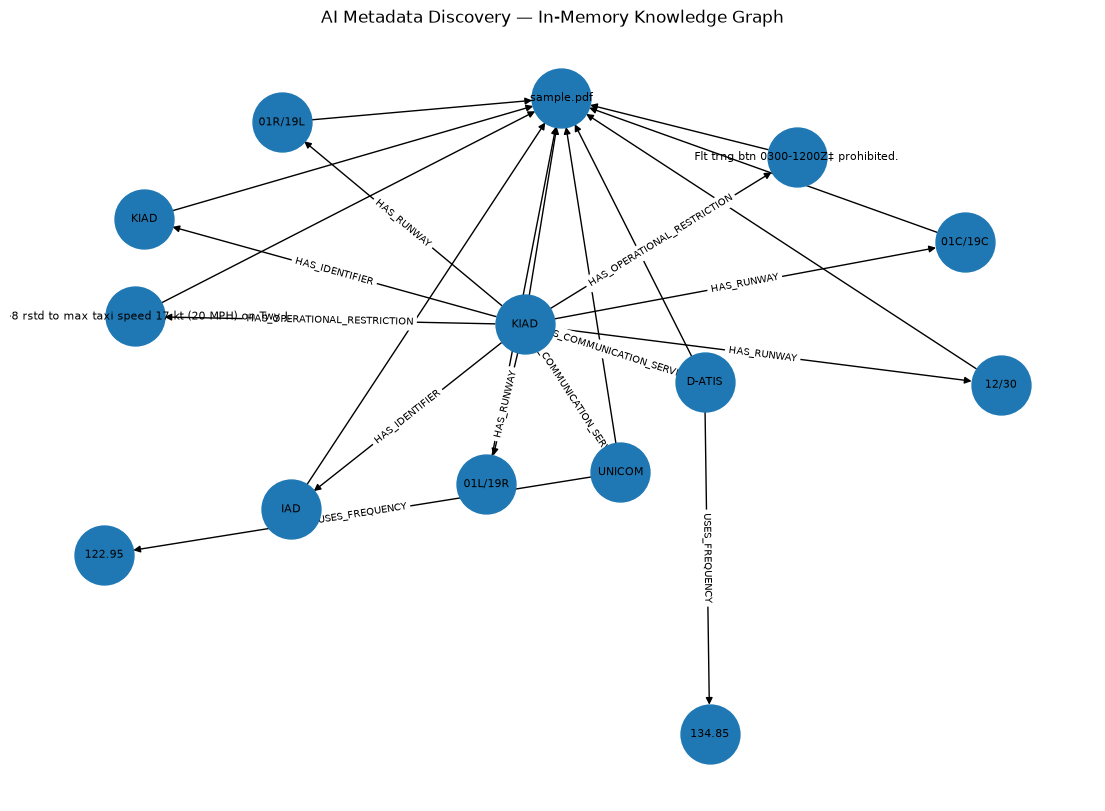

In [17]:
import matplotlib.pyplot as plt

G = result["graph"]
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=1.2)
labels = {node: attrs.get("display", node) for node, attrs in G.nodes(data=True)}

nx.draw_networkx(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=1800,
    font_size=8,
    arrows=True,
)

edge_labels = {}
for source, target, attrs in G.edges(data=True):
    if attrs.get("predicate") != "SUPPORTED_BY":
        edge_labels[(source, target)] = attrs.get("predicate")

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("AI Metadata Discovery — In-Memory Knowledge Graph")
plt.axis("off")
plt.show()

## LlamaIndex retrieval over the graph

Instead of asking Gemini directly about the PDF, graph entities and graph relationships become LlamaIndex documents. The final answer is therefore grounded in the extracted metadata/evidence layer.

In [18]:
from llama_index.core import Document, Settings, VectorStoreIndex
from llama_index.llms.google_genai import GoogleGenAI
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding


Settings.llm = GoogleGenAI(model=GEMINI_MODEL)
Settings.embed_model = GoogleGenAIEmbedding(model_name=GEMINI_EMBED_MODEL)


def graph_to_documents(G: nx.MultiDiGraph) -> list[Document]:
    documents = []

    for node_id, attrs in G.nodes(data=True):
        if attrs.get("label") == "Document":
            continue

        payload = attrs.get("payload") or {}
        supporting_text = payload.get("supporting_text", "")
        source_document = payload.get("source_document", "unknown")
        page = payload.get("page", "unknown")
        display_name = attrs.get("display", node_id)

        documents.append(Document(
            text=(
                f"Metadata entity type: {attrs.get('label')}\n"
                f"Entity: {display_name}\n"
                f"Properties: {payload}\n"
                f"Source evidence: {supporting_text}\n"
                f"Source: {source_document}, page {page}\n"
            ),
            metadata={
                "kind": "entity",
                "entity_type": attrs.get("label", "MetadataEntity"),
                "display": str(display_name),
                "source_document": str(source_document),
                "page": page if page is not None else "unknown",
                "supporting_text": str(supporting_text),
            },
        ))

    for source, target, attrs in G.edges(data=True):
        if attrs.get("predicate") == "SUPPORTED_BY":
            continue

        subject = G.nodes[source].get("display", source)
        obj = G.nodes[target].get("display", target)
        predicate = attrs.get("predicate")
        evidence = attrs.get("evidence", "")
        source_document = attrs.get("source_document", result["source_document"])
        page = attrs.get("page", 1)
        statement = f"{subject} --{predicate}--> {obj}"

        documents.append(Document(
            text=(
                f"Metadata relationship: {statement}\n"
                f"Source evidence: {evidence}\n"
                f"Source: {source_document}, page {page}\n"
            ),
            metadata={
                "kind": "relationship",
                "display": statement,
                "source_document": str(source_document),
                "page": page if page is not None else "unknown",
                "supporting_text": str(evidence),
            },
        ))

    return documents


retrieval_documents = graph_to_documents(result["graph"])
print(f"Created {len(retrieval_documents)} LlamaIndex retrieval documents.")

index = VectorStoreIndex.from_documents(retrieval_documents)
query_engine = index.as_query_engine(similarity_top_k=min(5, len(retrieval_documents)))
print("LlamaIndex retrieval layer is ready.")

Created 25 LlamaIndex retrieval documents.
LlamaIndex retrieval layer is ready.


## Ask grounded questions

The answer is generated from retrieved metadata, and the supporting evidence used by retrieval is printed below it.

In [19]:
async def ask_metadata(question: str, show_evidence: bool = True) -> str:
    prompt = (
        "Answer only from the retrieved aviation metadata and source evidence. "
        "Do not use outside aviation knowledge. "
        "If the answer is not present in the retrieved metadata, say that it was not found. "
        "Mention the source document and page when possible.\n\n"
        f"Question: {question}"
    )

    # Use async query in Jupyter
    response = await query_engine.aquery(prompt)

    print(f"QUESTION: {question}")
    print("-" * 80)
    print(str(response).strip())

    if show_evidence:
        print("\nRETRIEVED EVIDENCE")
        print("-" * 80)

        seen = set()
        shown = 0

        for source_node in response.source_nodes:
            metadata = source_node.node.metadata or {}

            evidence = str(
                metadata.get("supporting_text") or ""
            ).strip()

            source = metadata.get(
                "source_document",
                "unknown"
            )

            page = metadata.get(
                "page",
                "unknown"
            )

            if not evidence:
                continue

            key = (source, page, evidence)

            if key in seen:
                continue

            seen.add(key)
            shown += 1

            excerpt = evidence.replace("\n", " ")

            if len(excerpt) > 350:
                excerpt = excerpt[:347] + "..."

            print(
                f"{shown}. {source}, "
                f"page {page}: {excerpt}"
            )

            if shown >= 4:
                break

    return str(response).strip()

In [20]:
demo_questions = [
    "What identifiers were discovered for this airport?",
    "What runways were identified?",
    "What source evidence supports the D-ATIS information?",
]

for question in demo_questions:
    await ask_metadata(question)
    print("\n" + "=" * 100 + "\n")

QUESTION: What identifiers were discovered for this airport?
--------------------------------------------------------------------------------
The identifiers discovered for this airport (Washington Dulles International) are:

* **KIAD**: An ICAO identifier (Source: `sample.pdf`, page 1)
* **IAD**: An FAA/IATA identifier (Source: `sample.pdf`, page 1)

RETRIEVED EVIDENCE
--------------------------------------------------------------------------------
1. sample.pdf, page 1: KIAD
2. sample.pdf, page 1: WASHINGTON DULLES INTL
3. sample.pdf, page 1: IAD
4. sample.pdf, page 1: RWY 01C-19C: H11500X150 (CONC-GRVD)


QUESTION: What runways were identified?
--------------------------------------------------------------------------------
The following runways were identified:

* **01R/19L** (Length: 11,500 ft, Width: 150 ft, Surface: CONC-GRVD) — Source: `sample.pdf`, page 1
* **01L/19R** (Length: 9,400 ft, Width: 150 ft, Surface: CONC-GRVD) — Source: `sample.pdf`, page 1
* **12/30** (Length: 10,

## Optional interactive metadata assistant

For a live presentation, call `chat()` and ask questions until you type `exit`.

Remember, this is just a toy. 

In [21]:
def chat():
    print("Aviation Metadata Assistant")
    print("Type 'exit' to stop.\n")

    while True:
        question = input("You: ").strip()
        if question.lower() in {"exit", "quit"}:
            print("Goodbye.")
            break
        if not question:
            continue
        print()
        ask_metadata(question)
        print()


# Uncomment during a live demo.
# chat()

# References

1. **Federal Aviation Administration (FAA).** *Digital Chart Supplement / Airport Facility Directory.*  
   https://www.faa.gov/air_traffic/flight_info/aeronav/digital_products/dafd/

2. **FAA.** *Northeast Chart Supplement — July 9, 2026 edition.*  
   https://aeronav.faa.gov/Upload_313-d/supplements/CS_NE_20260709.pdf

3. **Docling Project.** *Docling Quickstart and DocumentConverter API.*  
   https://docling-project.github.io/docling/getting_started/quickstart/  
   https://docling-project.github.io/docling/reference/document_converter/

4. **Google.** *LangExtract — structured information extraction with source grounding.*  
   https://github.com/google/langextract

5. **Google Developers Blog.** *Introducing LangExtract: a Gemini-powered information extraction library.*  
   https://developers.googleblog.com/introducing-langextract-a-gemini-powered-information-extraction-library/

6. **Pydantic.** *Pydantic documentation.*  
   https://docs.pydantic.dev/

7. **LangChain.** *LangGraph overview.*  
   https://docs.langchain.com/oss/python/langgraph/overview

8. **NetworkX Developers.** *NetworkX documentation.*  
   https://networkx.org/documentation/stable/

9. **LlamaIndex.** *LlamaIndex open-source framework.*  
   https://github.com/run-llama/llama_index

10. **Google AI for Developers.** *Gemini model documentation.*  
    https://ai.google.dev/gemini-api/docs/models

11. **Google AI for Developers.** *Gemini embeddings.*  
    https://ai.google.dev/gemini-api/docs/embeddings